In [7]:
import matplotlib.pyplot as plt
import numpy as np

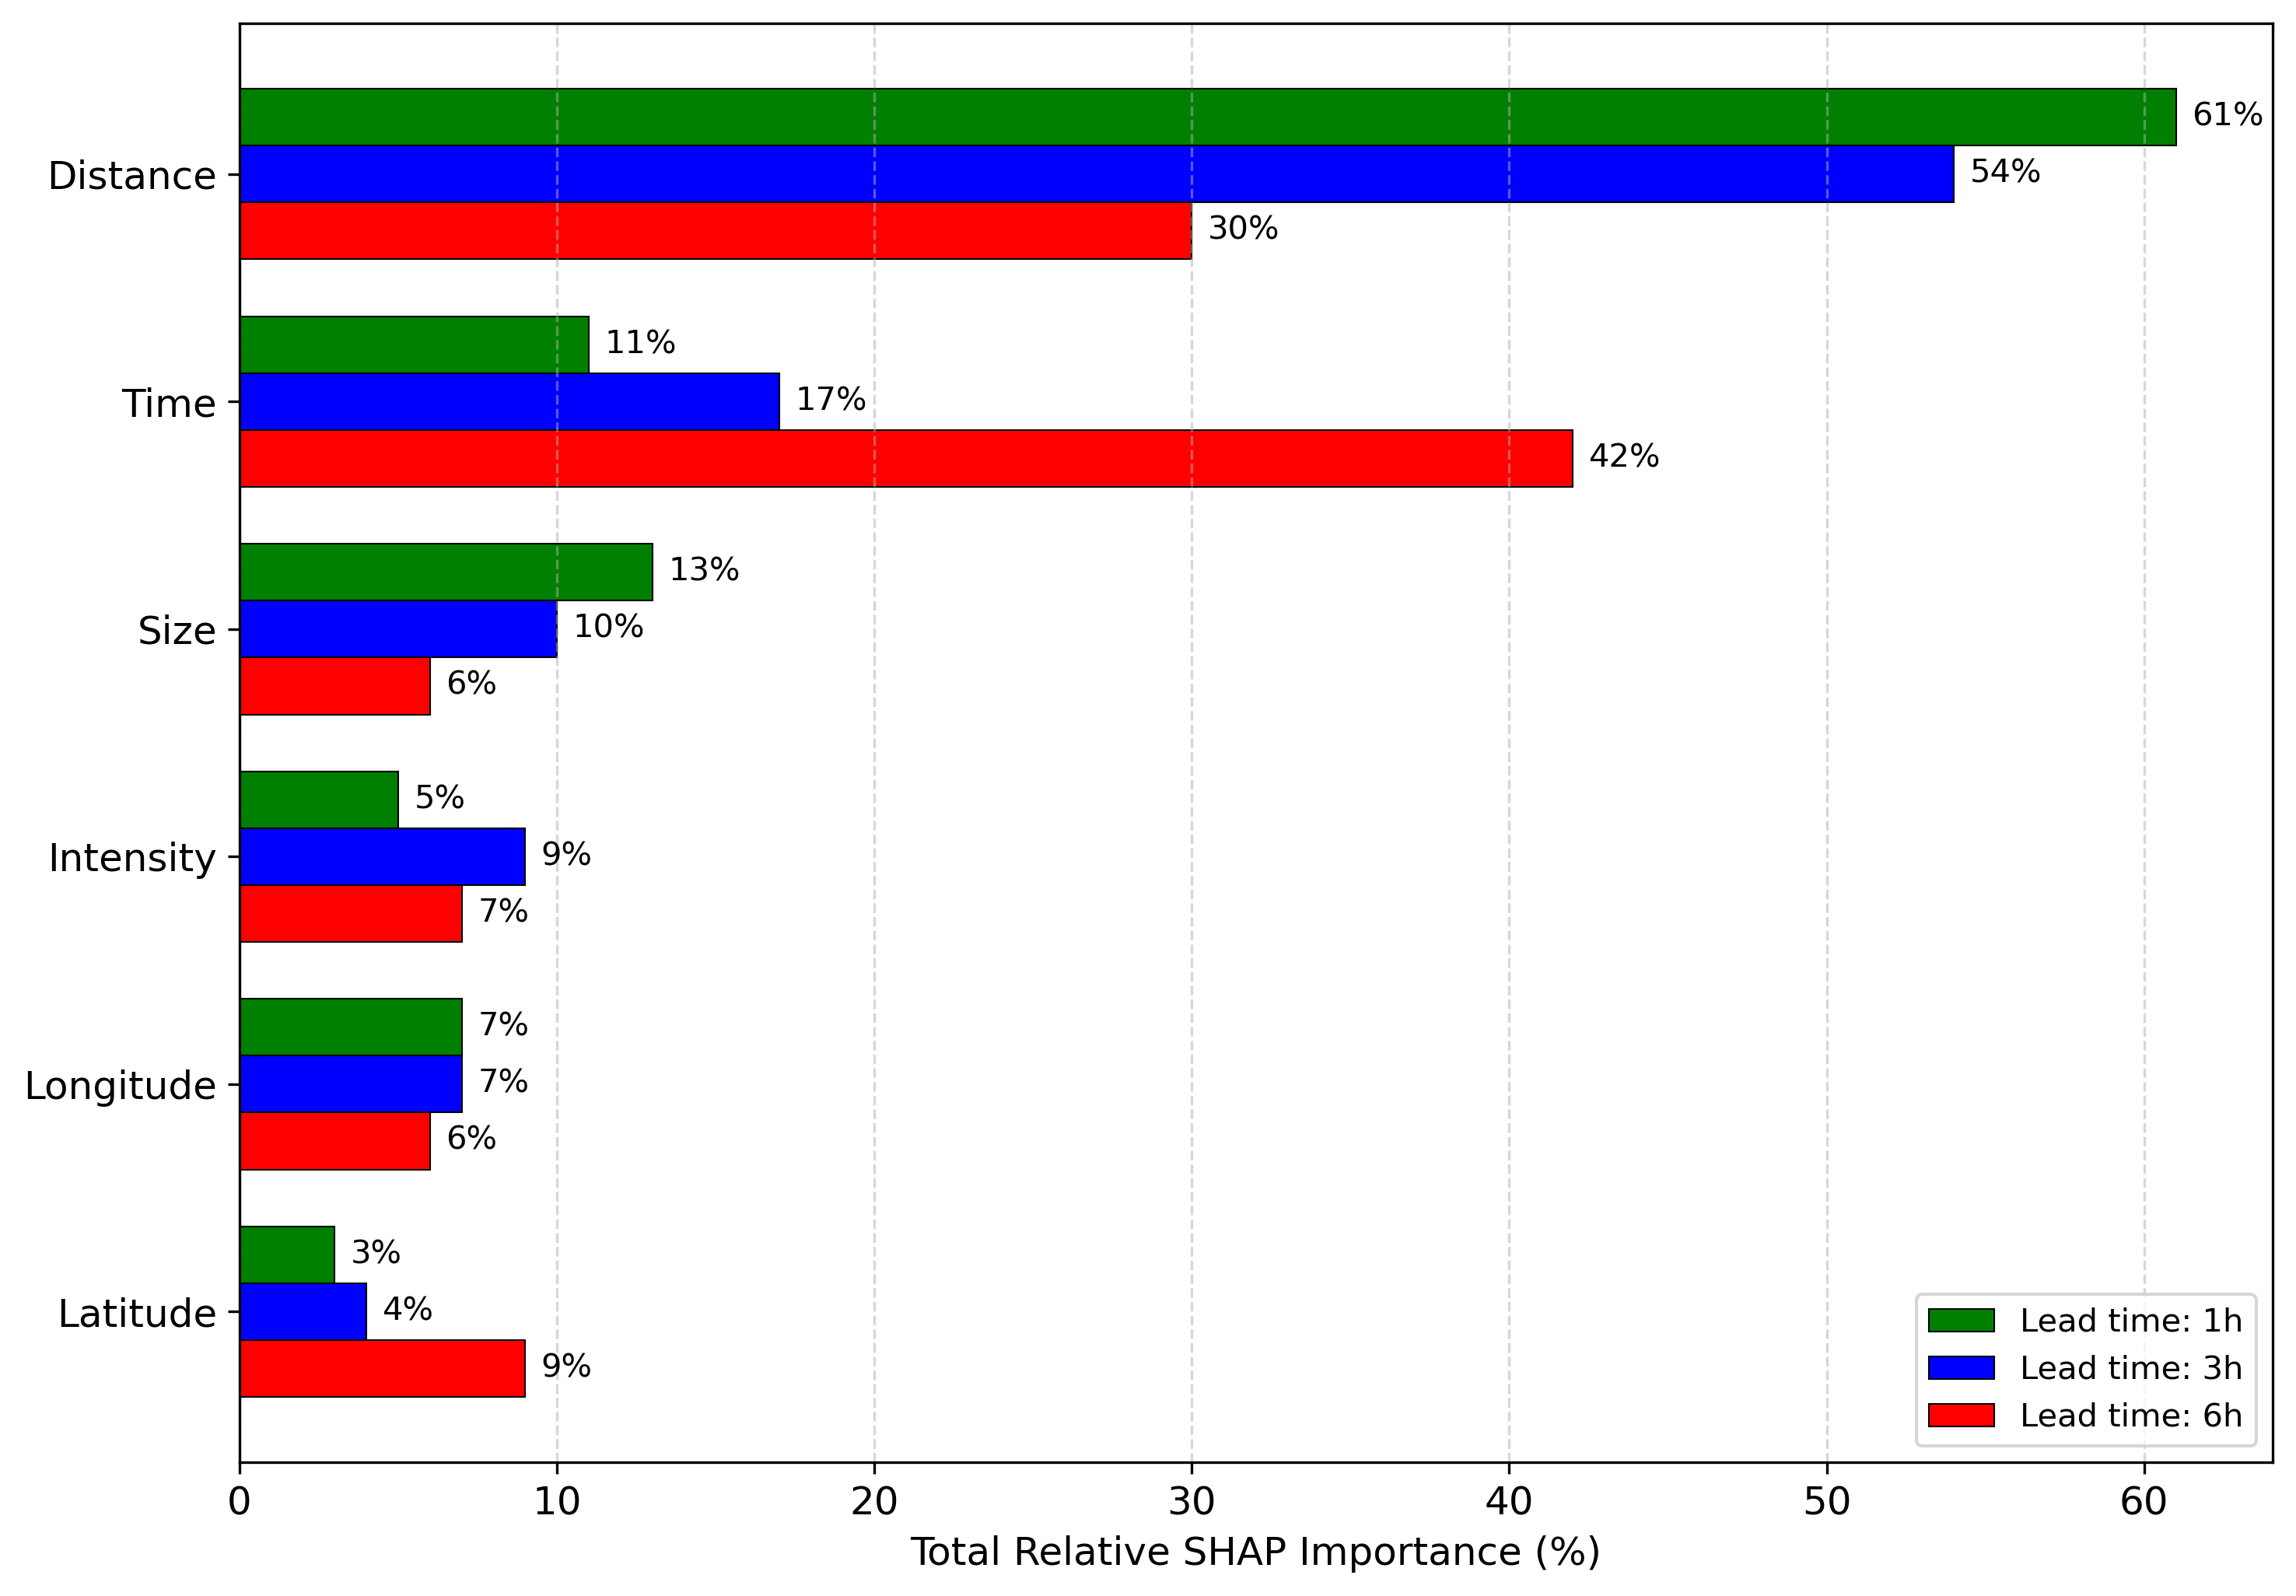

In [8]:
# Optional: use serif font for LaTeX-style publication
# plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12

# Data
features = ['Intensity', 'Distance', 'Size', 'Longitude', 'Latitude', 'Time']
shap_1h_raw = np.array([5, 61.1, 13.1, 7.2, 2.6, 11])
shap_3h_raw = np.array([8.6, 53.5, 10.1, 6.8, 4.5, 16.6])
shap_6h_raw = np.array([7.3, 29.6, 6, 5.6, 9.4, 42.0])

# Rounded SHAP values
shap_1h = np.round(shap_1h_raw).astype(int)
shap_3h = np.round(shap_3h_raw).astype(int)
shap_6h = np.round(shap_6h_raw).astype(int)

# Sorting by total importance
total_importance = shap_1h + shap_3h + shap_6h
sort_idx = np.argsort(-total_importance)
features_sorted = np.array(features)[sort_idx]
shap_1h_sorted = shap_1h[sort_idx]
shap_3h_sorted = shap_3h[sort_idx]
shap_6h_sorted = shap_6h[sort_idx]

# Plot
bar_height = 0.25
y = np.arange(len(features))

fig = plt.figure(figsize=(10, 7), dpi=300)  # High DPI

plt.barh(y - bar_height, shap_1h_sorted, height=bar_height, color='green',
         edgecolor='black', linewidth=0.5, label='Lead time: 1h')
plt.barh(y, shap_3h_sorted, height=bar_height, color='blue',
         edgecolor='black', linewidth=0.5, label='Lead time: 3h')
plt.barh(y + bar_height, shap_6h_sorted, height=bar_height, color='red',
         edgecolor='black', linewidth=0.5, label='Lead time: 6h')

plt.yticks(y, features_sorted)
plt.gca().invert_yaxis()

plt.xlabel("Total Relative SHAP Importance (%)")
plt.legend(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Annotate
for i in range(len(features)):
    for dy, val in zip([-bar_height, 0, bar_height], [shap_1h_sorted[i], shap_3h_sorted[i], shap_6h_sorted[i]]):
        plt.text(val + 0.5, y[i] + dy, f"{val}%", va='center', fontsize=10)

plt.tight_layout()

# Save high-res version
plt.savefig("shap_feature_importance.png", dpi=300, bbox_inches='tight')
# Optional: use PDF for vector output
# plt.savefig("shap_feature_importance.pdf", bbox_inches='tight')

plt.show()
